# Exploratory Data Analysis — Steel Plates Faults

The goal of this notebook is to perform exploratory data analysis on the Steel Plates Faults dataset.

The analysis focuses on:
- dataset structure and basic characteristics
- data quality checks
- descriptive statistics
- class distribution
- feature distributions
- correlations between variables
- preliminary observations useful for later modeling

The dataset contains steel plate fault observations described by numerical features and fault labels. The original task is classification of fault type.

In [37]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff


## Load the dataset

In [38]:
dataset_path = Path("../dataset/php9xWOpn.arff")

data, meta = arff.loadarff(dataset_path)
df = pd.DataFrame(data)
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 34 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      1941 non-null   float64
 1   V2      1941 non-null   float64
 2   V3      1941 non-null   float64
 3   V4      1941 non-null   float64
 4   V5      1941 non-null   float64
 5   V6      1941 non-null   float64
 6   V7      1941 non-null   float64
 7   V8      1941 non-null   float64
 8   V9      1941 non-null   float64
 9   V10     1941 non-null   float64
 10  V11     1941 non-null   float64
 11  V12     1941 non-null   float64
 12  V13     1941 non-null   float64
 13  V14     1941 non-null   float64
 14  V15     1941 non-null   float64
 15  V16     1941 non-null   float64
 16  V17     1941 non-null   float64
 17  V18     1941 non-null   float64
 18  V19     1941 non-null   float64
 19  V20     1941 non-null   float64
 20  V21     1941 non-null   float64
 21  V22     1941 non-null   float64
 22  V23     194

Convert Class column from object to string

In [39]:
df["Class"] = df["Class"].apply(lambda x: x.decode("utf-8") if isinstance(x, bytes) else x).astype("string")
print(df["Class"].dtype)

string


## Description of the dataframe

In [40]:
print(df.head())
print(df.shape)
print(df.columns.tolist())

print(df["Class"].value_counts())

       V1      V2         V3         V4      V5    V6     V7        V8    V9  \
0    42.0    50.0   270900.0   270944.0   267.0  17.0   44.0   24220.0  76.0   
1   645.0   651.0  2538079.0  2538108.0   108.0  10.0   30.0   11397.0  84.0   
2   829.0   835.0  1553913.0  1553931.0    71.0   8.0   19.0    7972.0  99.0   
3   853.0   860.0   369370.0   369415.0   176.0  13.0   45.0   18996.0  99.0   
4  1289.0  1306.0   498078.0   498335.0  2409.0  60.0  260.0  246930.0  37.0   

     V10     V11  V12  V13    V14     V15     V16     V17     V18     V19  \
0  108.0  1687.0  1.0  0.0   80.0  0.0498  0.2415  0.1818  0.0047  0.4706   
1  123.0  1687.0  1.0  0.0   80.0  0.7647  0.3793  0.2069  0.0036  0.6000   
2  125.0  1623.0  1.0  0.0  100.0  0.9710  0.3426  0.3333  0.0037  0.7500   
3  126.0  1353.0  0.0  1.0  290.0  0.7287  0.4413  0.1556  0.0052  0.5385   
4  126.0  1353.0  0.0  1.0  185.0  0.0695  0.4486  0.0662  0.0126  0.2833   

      V20  V21     V22     V23     V24     V25     V26  

Check for duplicate rows and missing values

In [41]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

print("Duplicate rows:", df.duplicated().sum())

Series([], dtype: int64)
Duplicate rows: 0


Show standard descriptive statistics for numeric columns

In [42]:
print(df.describe().T)

      count          mean           std        min          25%           50%  \
V1   1941.0  5.711360e+02  5.206907e+02     0.0000      51.0000  4.350000e+02   
V2   1941.0  6.179645e+02  4.976274e+02     4.0000     192.0000  4.670000e+02   
V3   1941.0  1.650685e+06  1.774578e+06  6712.0000  471253.0000  1.204128e+06   
V4   1941.0  1.650739e+06  1.774590e+06  6724.0000  471281.0000  1.204136e+06   
V5   1941.0  1.893878e+03  5.168460e+03     2.0000      84.0000  1.740000e+02   
V6   1941.0  1.118552e+02  3.012092e+02     2.0000      15.0000  2.600000e+01   
V7   1941.0  8.296600e+01  4.264829e+02     1.0000      13.0000  2.500000e+01   
V8   1941.0  2.063121e+05  5.122936e+05   250.0000    9522.0000  1.920200e+04   
V9   1941.0  8.454869e+01  3.213428e+01     0.0000      63.0000  9.000000e+01   
V10  1941.0  1.301937e+02  1.869099e+01    37.0000     124.0000  1.270000e+02   
V11  1941.0  1.459160e+03  1.445778e+02  1227.0000    1358.0000  1.364000e+03   
V12  1941.0  4.003091e-01  4

## Check if classes are balanced via class distribution plot

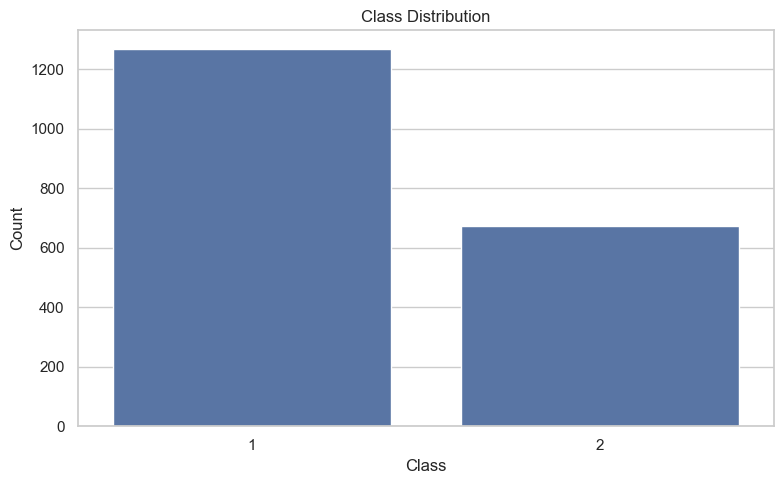

In [43]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Class")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Separate features and target

In [44]:
x = df.drop(columns=["Class"])
y = df["Class"]

print(x.shape)
print(y.shape)

(1941, 33)
(1941,)


## Distribution of numeric features

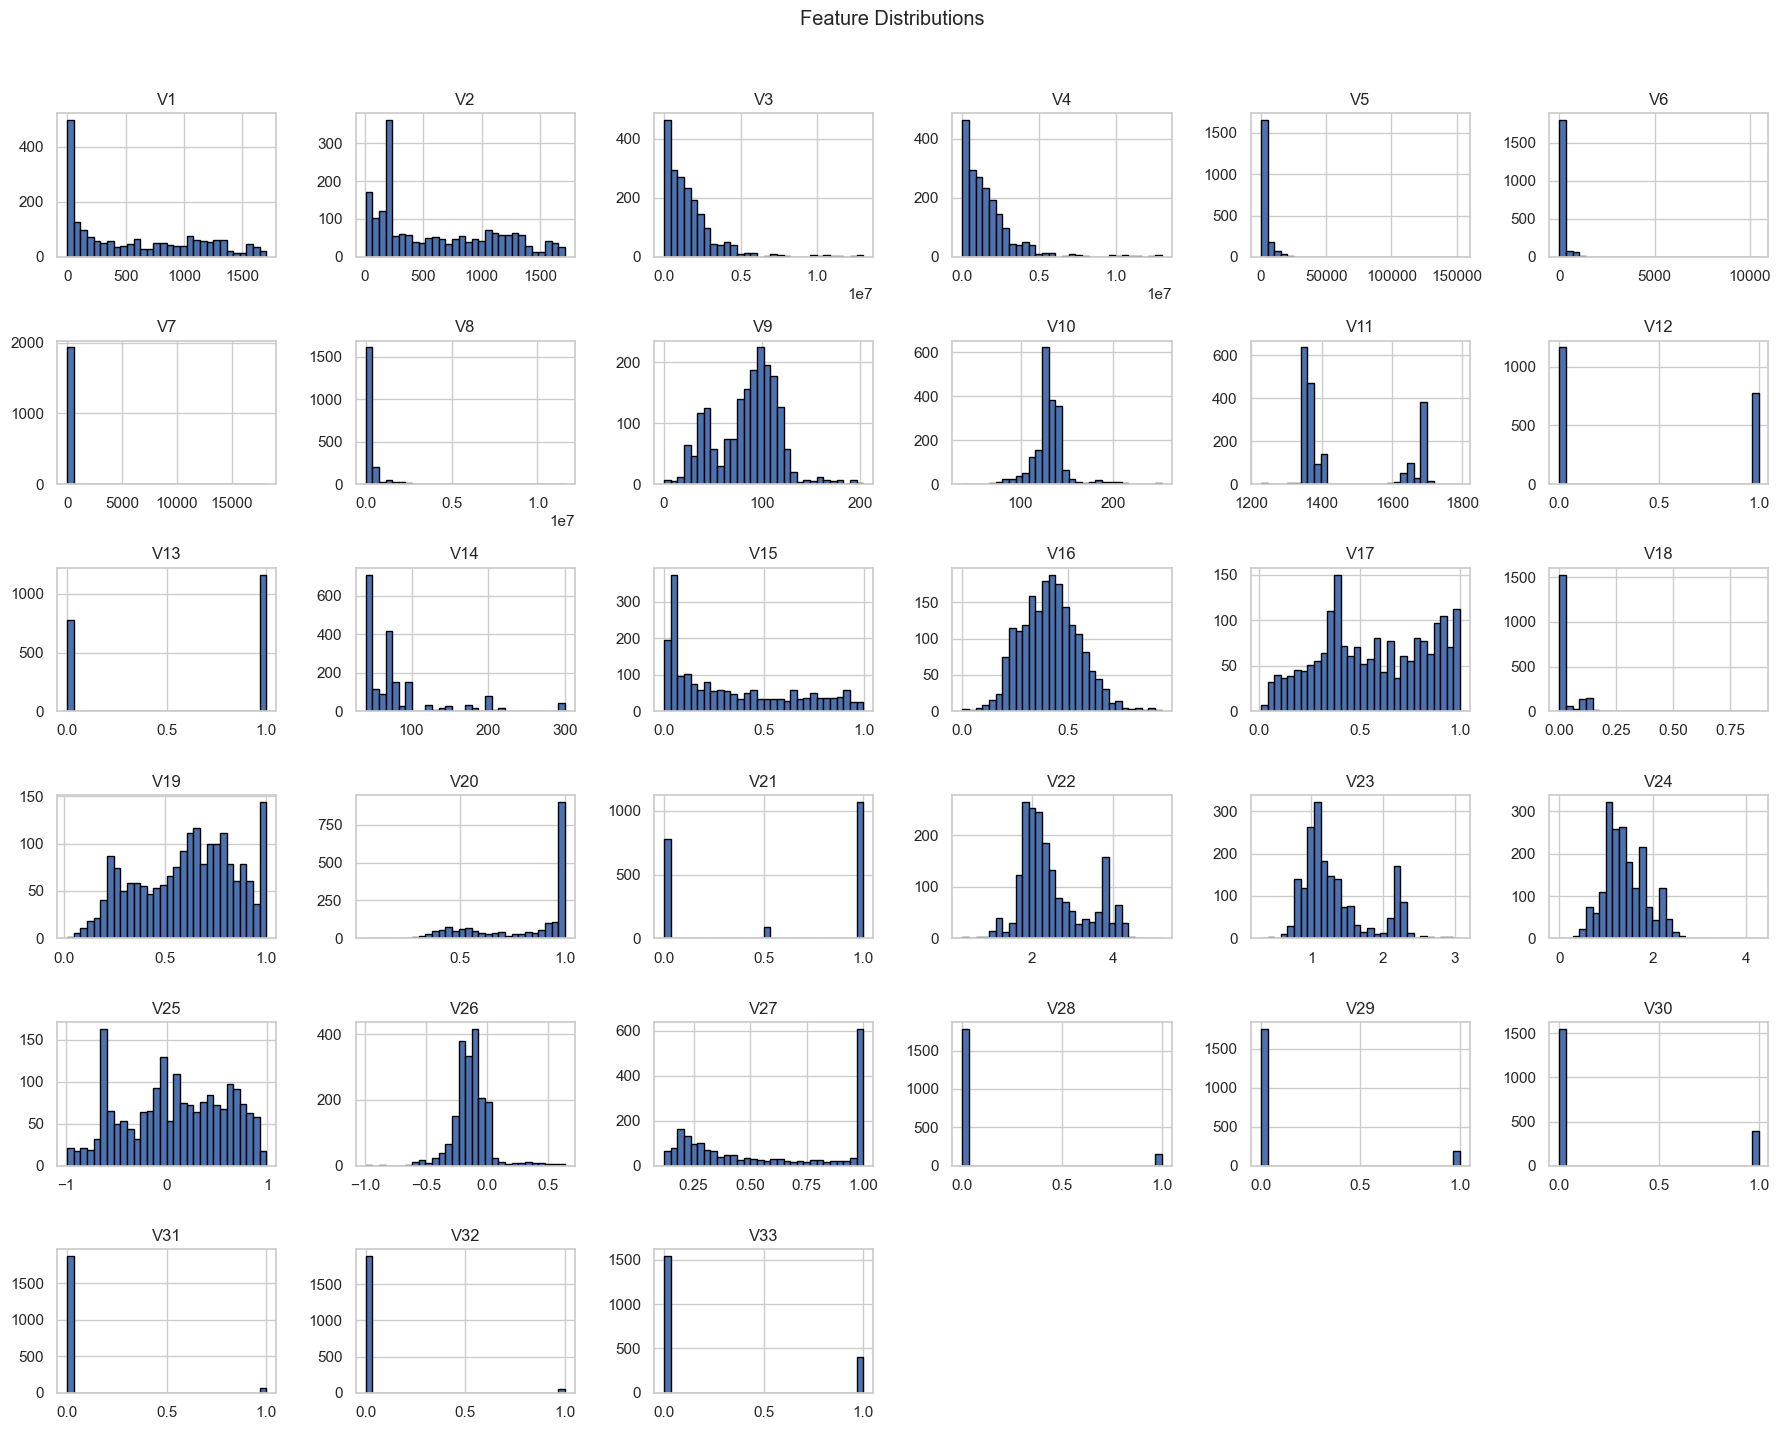

In [45]:
x.hist(figsize=(18, 14), bins=30, edgecolor="black")
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

### Conclusion

The histograms show that many features are not normally distributed. Several variables, especially V3–V8, are strongly right-skewed, with most values concentrated near zero and a small number of very large observations. Some features such as V12, V13, V21, and V28–V33 are binary or highly sparse, while others show more continuous and spread-out distributions.

## Boxplot per feature

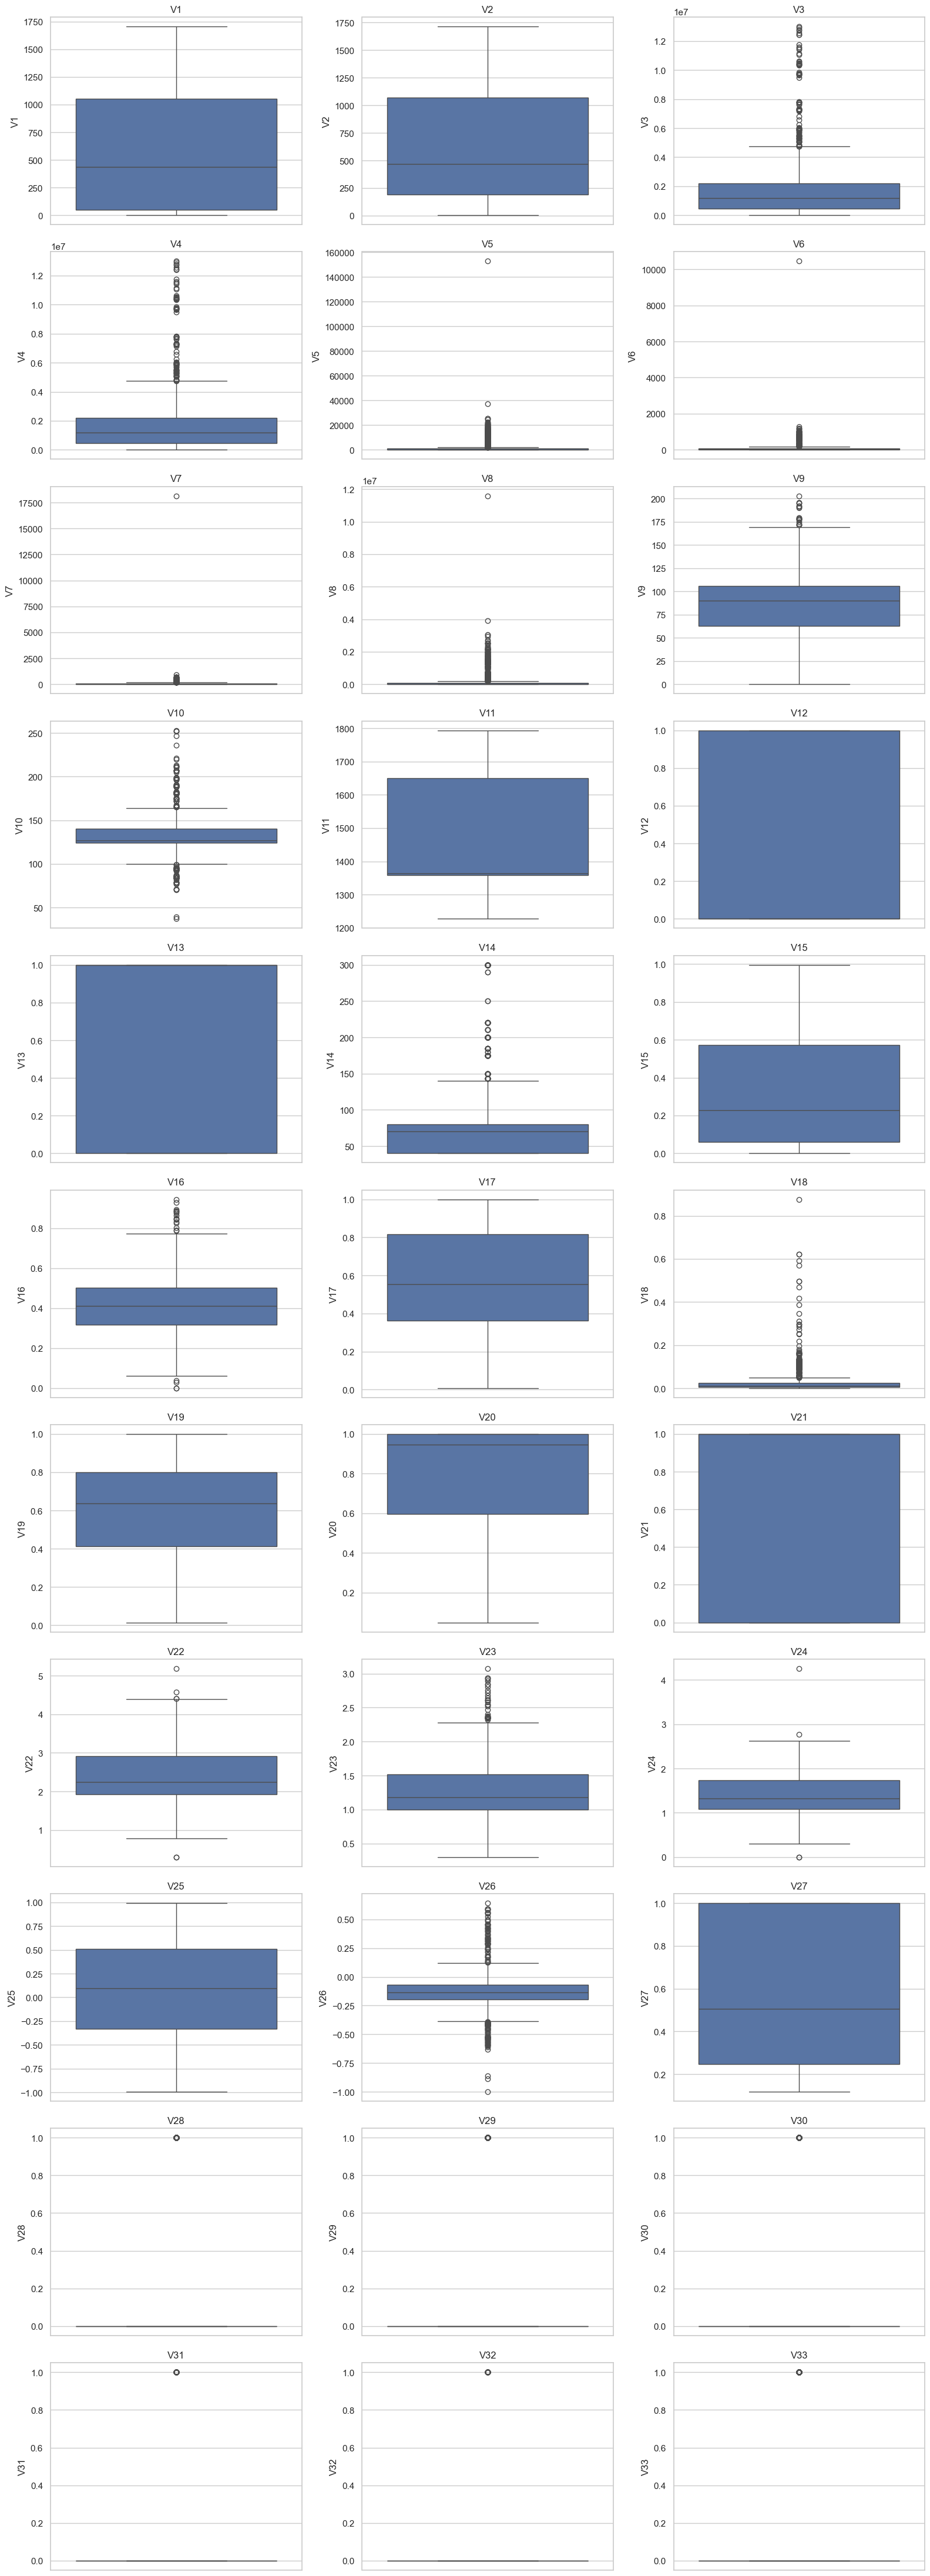

In [46]:
numeric_cols = X.select_dtypes(include=[np.number]).columns

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)

for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

### Conclusion

The boxplots show that the dataset contains many outliers and several skewed variables, especially V3–V8. Some features, such as V28–V33, are almost always zero, so they behave like sparse binary indicators. The variables also have very different scales and ranges.

## Correlation Heatmap for features

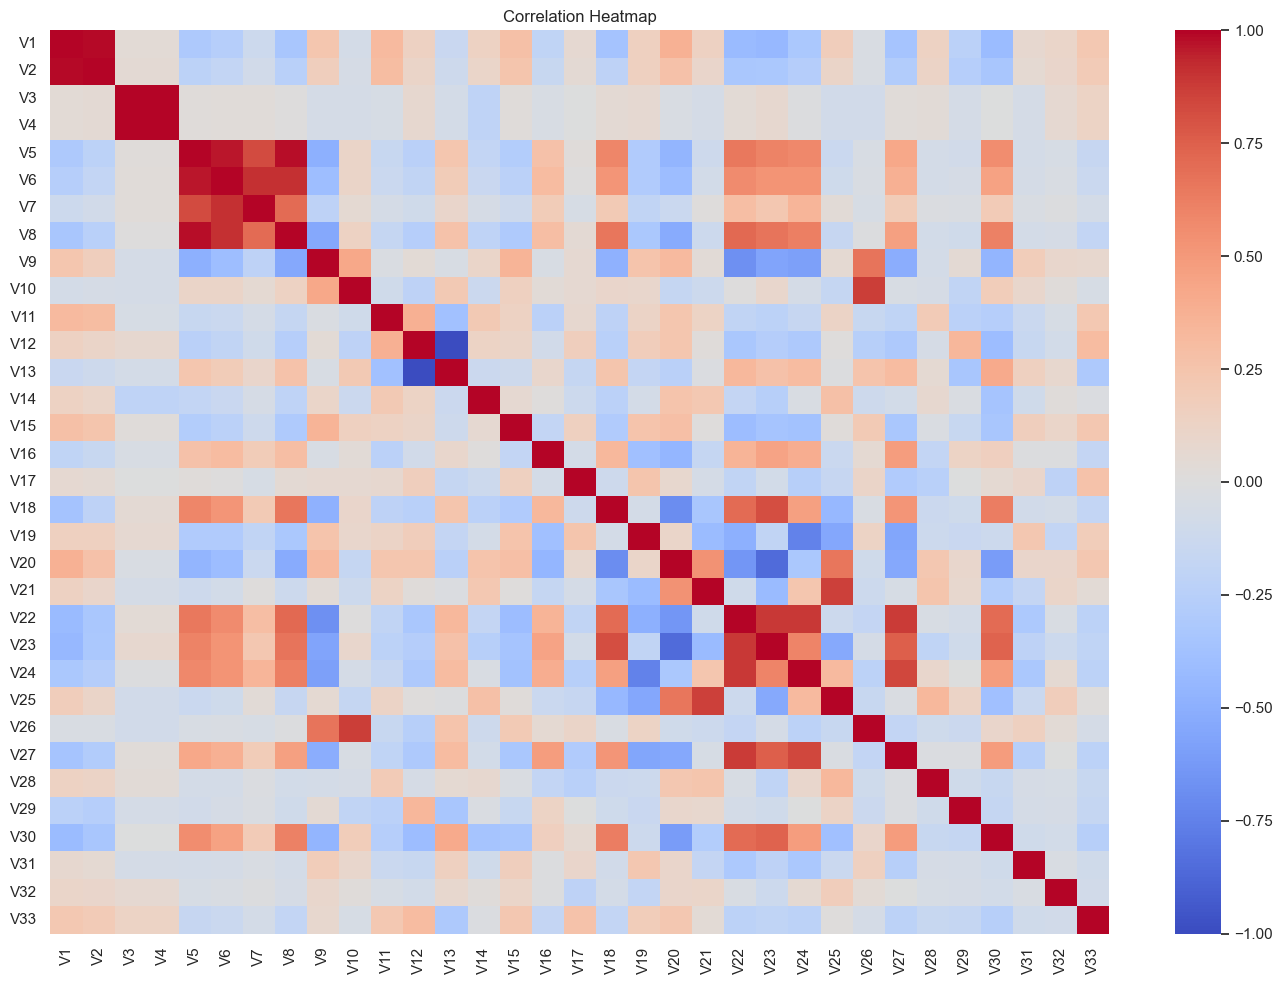

In [47]:
corr = X.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Rank the correlations

In [48]:
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print(corr_pairs.head(15))

V12  V13   -1.000000
V3   V4     1.000000
V1   V2     0.988314
V5   V8     0.978952
     V6     0.966644
V6   V8     0.912956
     V7     0.912436
V22  V23    0.888919
     V24    0.882974
     V27    0.877768
V10  V26    0.870160
V21  V25    0.862670
V20  V23   -0.855414
V24  V27    0.838188
V5   V7     0.827199
dtype: float64


### Conclusion

The correlation analysis shows that several features are very strongly related. In particular, pairs such as V3–V4, V1–V2, and V5–V8 have extremely high positive correlations, which suggests possible redundancy between variables. There is also a perfect negative correlation between V12 and V13, meaning they likely carry the same information in opposite form.

## Check how features divide the classes

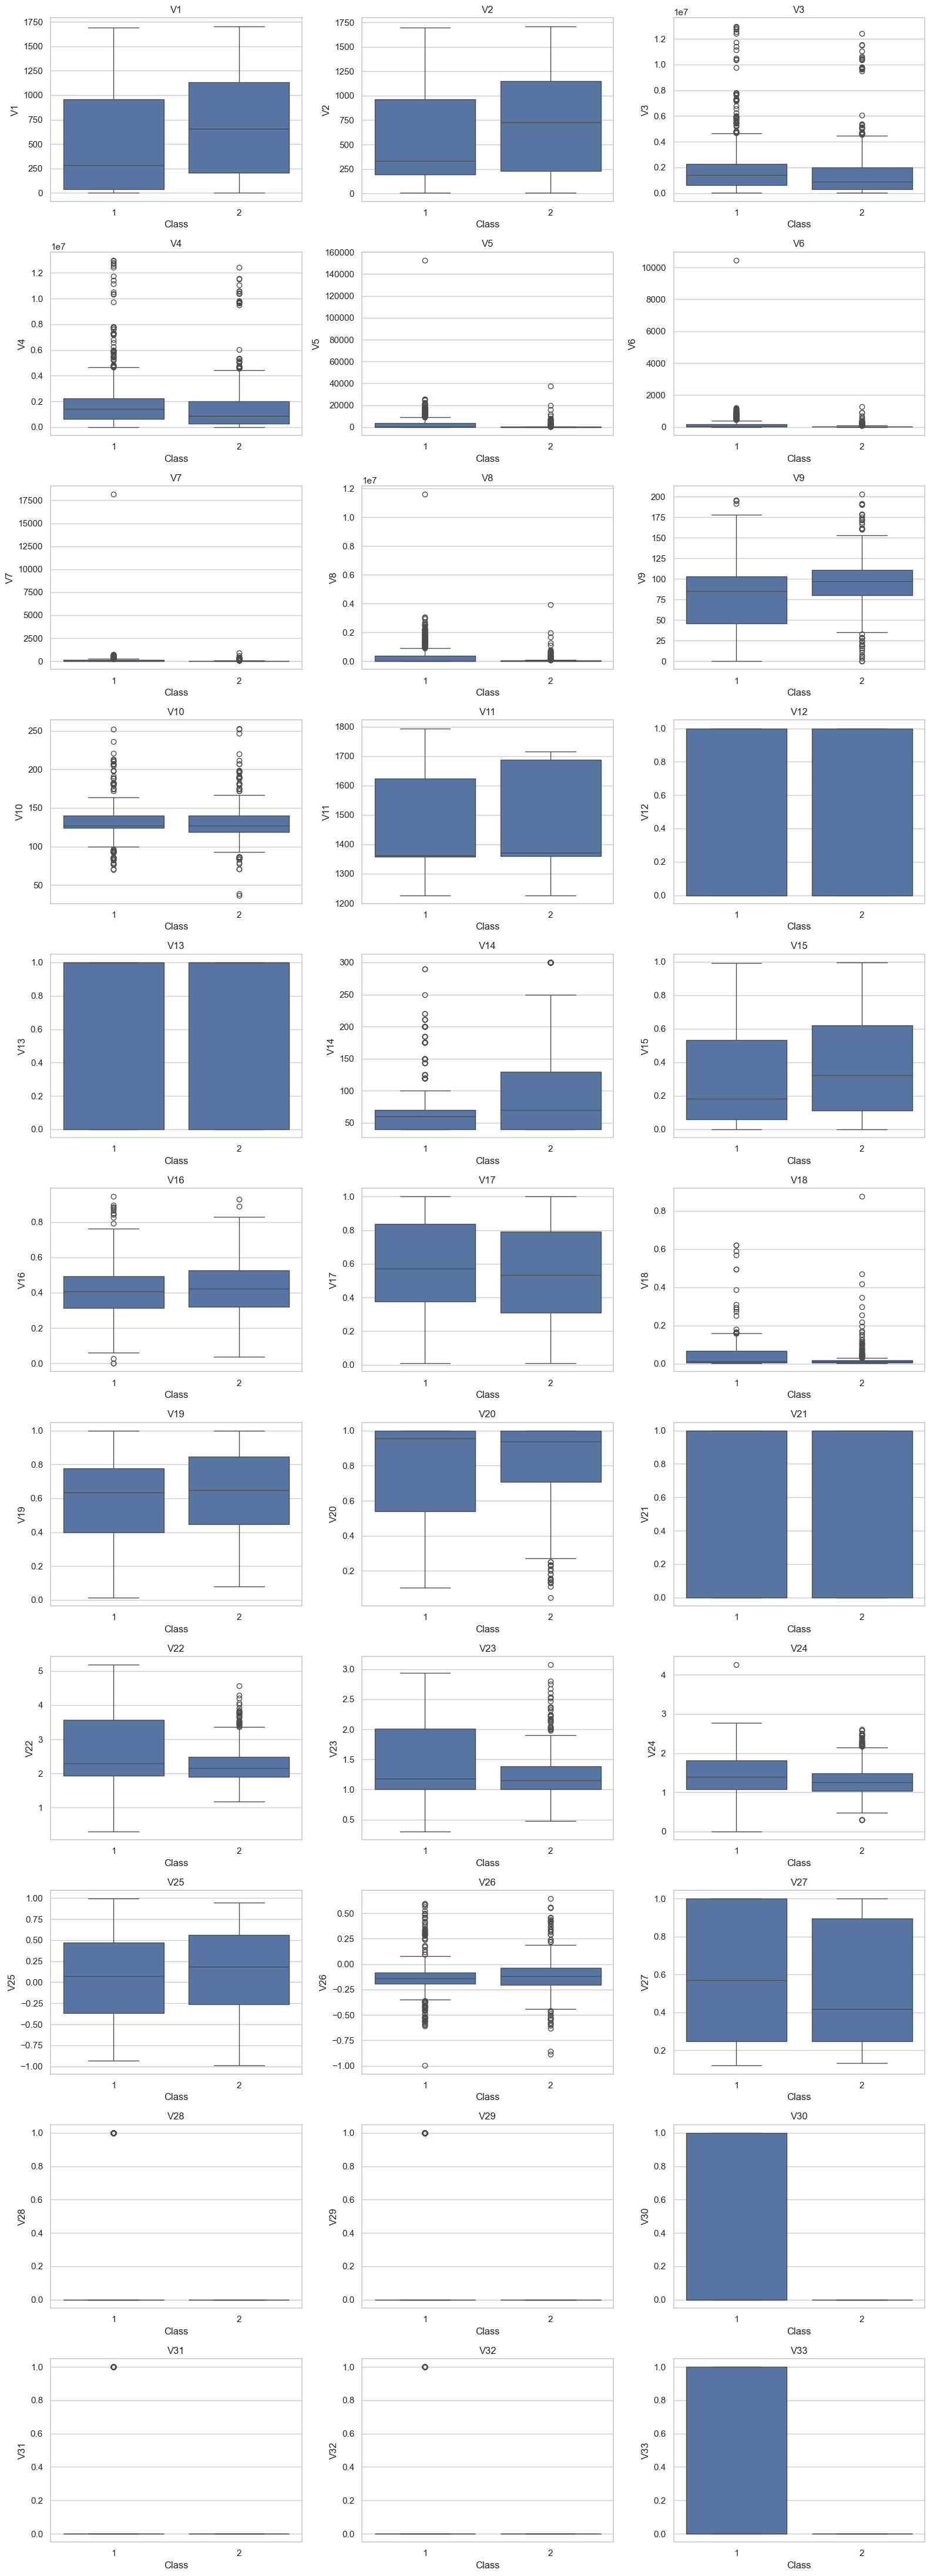

In [49]:
selected_cols = x.select_dtypes(include=[np.number]).columns

n_cols = 3
n_rows = int(np.ceil(len(selected_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, selected_cols):
    sns.boxplot(data=df, x="Class", y=col, ax=ax)
    ax.set_title(col)

for ax in axes[len(selected_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Conclusion

The class-wise boxplots show that some features differ visibly between the two classes, but the separation is usually only partial. The clearest differences appear in variables such as V1, V2, V14, V20, V22, V23, and V24, where the medians or overall distributions shift between classes. On the other hand, several features such as V11, V12, V13, V21, and V28–V32 show little or almost no visible separation.

Many variables still contain strong outliers and skewed distributions, especially among the earlier features, which makes class separation harder to judge from boxplots alone. Overall, the plot suggests that no single feature separates the classes perfectly, but several variables show useful differences, so classification will likely benefit from combining multiple features.

## Final EDA conclusion

The exploratory analysis showed that the dataset is composed mainly of numerical features with a binary target variable `Class`. No major structural issues were found apart from the need to convert the target column from object/bytes to string format.

The feature distributions revealed that many variables are not normally distributed. Several features, especially V3–V8, are strongly right-skewed and contain many extreme outliers. Some variables, such as V12, V13, V21, and V28–V33, behave like binary or sparse indicator features, while others are more continuous.

The boxplots confirmed that the dataset contains many outliers, large scale differences, and multiple skewed variables, which suggests that preprocessing will be important before modeling.

The correlation analysis showed that some features are highly redundant. In particular, pairs such as V1–V2 and V3–V4 are extremely strongly correlated, while V12 and V13 are perfectly negatively correlated. This means that some variables likely carry overlapping information.

## Planned evaluation metrics

Since the task is binary classification, regression metrics such as MSE or MAE are not appropriate.

The main metric we plan to utilize is F1-score, because it combines precision and recall and is more informative than plain accuracy when the classes are not perfectly balanced or when both false positives and false negatives matter.

I also plan to report:
- Accuracy – simple overall proportion of correctly classified samples
- Precision – how many predicted positive samples are actually correct
- Recall – how many real positive samples are correctly detected
- Confusion matrix – to show the exact distribution of correct and incorrect predictions across both classes

If the final model produces probabilities, I would also include:
- ROC-AUC – to evaluate how well the model separates the two classes across different thresholds